# Hallucination Detection

<img src="https://live.staticflickr.com/65535/54208132682_73767c3560_b.jpg" alt="Embedded Photo" width="500">

*Image generated using the DALL-E model.*

## Introduction

Language models help us in everyday tasks, such as improving texts, writing code, or answering questions.
They are also increasingly used in fields such as medicine and education.

However, how can we know if the responses they generate are correct? Language models do not always possess full knowledge on a given topic, yet they may formulate answers that sound credible but are actually misleading. Such incorrect answers are called hallucinations.

## Task

In this task, you will tackle the detection of hallucinations in answers to factual questions generated by large language models (LLMs).
You will analyze a dataset that helps assess whether the answers generated by the language model are actually correct or contain hallucinations.

Each example in the dataset contains:

- **Question** e.g., "What is the primary responsibility of the US Department of Defense?"
- **Language model answer** e.g., "The primary responsibility is to defend the country."
- **Tokens** related to answer generation.
- **Four alternative answers** generated by the same model with higher temperature.
- **Tokens of alternative answers** generated by the same model with higher temperature.
- **Probabilities of alternative answers** generated by the same model with higher temperature.
- **Label (`is_correct`)** indicating whether the main answer is correct according to a trusted source.


Example:
```json
[
    {
        "question_id": 34,
        "question": "What is the name of the low-cost carrier that operates as a wholly owned subsidiary of Singapore Airlines?",
        "answer": "Scoot is the low-cost carrier that operates as a wholly owned subsidiary of Singapore Airlines.",
        "tokens": [" Sco", "ot", " is", ..., " Airlines", ".", "\n"],
        "supporting_answers": [
            "As a wholly owned subsidiary of Singapore Airlines, <answer> Scoot </answer> stands as a low-cost carrier that revolutionized air travel in the region.",
            "Scoot, a subsidiary of <answer> Singapore Airlines </answer> , is the low-cost carrier that operates under the same brand.",
            "<answer> Scoot </answer> is the low-cost carrier that operates as a wholly owned subsidiary of Singapore Airlines.",
            "Singapore Airlines operates a low-cost subsidiary named <answer> Scoot </answer> , offering affordable and efficient air travel options to passengers."
        ],
        "supporting_tokens": [
            [" As", " a", ..., ".", "<answer>"],
            [" Sco", "ot", ..., " brand", ".", "\n"],
            ["<answer>", " Sco", ..., ".", "\n"],
            [" Singapore", " Airlines", ..., ".", "\n"]
        ],
        "supporting_probabilities": [
            [0.0029233775567263365, 0.8621460795402527, ..., 0.018515007570385933],
            [0.42073577642440796, 0.9999748468399048, ..., 0.9166142344474792],
            [0.3258324861526489, 0.9969879984855652, ..., 0.921079695224762],
            [0.11142394691705704, 0.960810661315918, ..., 0.9557166695594788]
        ],
        "is_correct": true
    },
    .
    .
    .
]
```

### Data
The data available for you in this task are:

* `train.json` - dataset containing 2967 questions and answers.
* `valid.json` - 990 additional questions.


### Scoring Criteria

ROC AUC (Receiver Operating Characteristic Area Under Curve) is a measure of the quality of a binary classifier. It shows the model's ability to distinguish between two classes - here, hallucination (false) and correct answer (true).

- **ROC (Receiver Operating Characteristic)**: A graph showing the relationship between True Positive Rate (sensitivity) and False Positive Rate (1-specificity) at various decision thresholds.
- **AUC (Area Under Curve)**: The area under the ROC curve, which takes values from 0 to 1:
  - **1.0**: Perfect model.
  - **0.5**: Random model (no ability to distinguish classes).

The higher the AUC value, the better the model performs in classification.

You can score between 0 and 100 points for this task. The score will be linearly scaled depending on the ROC AUC value:

- **ROC AUC ≤ 0.7**: 0 points.
- **ROC AUC ≥ 0.82**: 100 points.
- **Values between 0.7 and 0.82**: linearly scaled.

Score formula:
$$
\text{Points} = 
\begin{cases} 
0 & \text{for } \text{ROC AUC} \leq 0.7 \\
100 \times \frac{\text{ROC AUC} - 0.7}{0.82 - 0.7} & \text{for } 0.7 < \text{ROC AUC} < 0.82 \\
100 & \text{for } \text{ROC AUC} \geq 0.82
\end{cases}
$$


## Constraints
* Your solution will be tested on the Competition Platform without internet access and in a GPU-less environment.
* Evaluation of your final solution on the Competition Platform cannot exceed 5 minutes without a GPU.
* List of allowed libraries: `xgboost`, `scikit-learn`, `numpy`, `pandas`, `matplotlib`.


## Submission Files
This notebook supplemented with your solution (see `predict_hallucinations` function).

## Evaluation
Remember, during checking, the `FINAL_EVALUATION_MODE` flag will be set to `True`.

You can score between 0 and 100 points for this task. The number of points you earn will be calculated on the (secret) test set on the Competition Platform based on the above formula, rounded to an integer. If your solution does not meet the above criteria or does not execute correctly, you will receive 0 points for the task.


# Starting Code
In this section, we initialize the environment by importing the necessary libraries and functions. The prepared code will facilitate efficient data manipulation and building a proper solution.

In [1]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################

FINAL_EVALUATION_MODE = False  # During the evaluation of your solution, we will change this value to True

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import sklearn as sk
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.dummy import DummyClassifier


def download_data(train=("1TGEDaxw4GKfSq0fpqSk0wRpUSc8GgZN0", "train.json"),
                  valid=("1qrr7bZk6Uct8DeC-V8Bc1qD5su56ryFd", "valid.json")):
    """Downloads the dataset from Google Drive and saves it in the 'data' folder."""
    import gdown
    import shutil
    
    # Create or reset the 'data' folder
    if not os.path.exists('data'):
        os.makedirs('data')
    else:
        shutil.rmtree('data')
        os.makedirs('data')

    GDRIVE_DATA = [train, valid]
    
    for file_id, file_name in GDRIVE_DATA:        
        # Download the file from Google Drive and save it in the 'data' folder
        url = f'https://drive.google.com/uc?id={file_id}'
        output = f'data/{file_name}'
        gdown.download(url, output, quiet=False)
        
        print(f"Downloaded: {file_name}")

# Download data only if not in FINAL_EVALUATION_MODE
if not FINAL_EVALUATION_MODE:
    download_data()


Downloading...
From: https://drive.google.com/uc?id=1TGEDaxw4GKfSq0fpqSk0wRpUSc8GgZN0
To: c:\Users\raian\source\repos\AI\IOAI_prep\poland\2_1\hallucinations\data\train.json
100%|██████████| 14.2M/14.2M [00:01<00:00, 9.78MB/s]


Downloaded: train.json


Downloading...
From: https://drive.google.com/uc?id=1qrr7bZk6Uct8DeC-V8Bc1qD5su56ryFd
To: c:\Users\raian\source\repos\AI\IOAI_prep\poland\2_1\hallucinations\data\valid.json
100%|██████████| 4.77M/4.77M [00:00<00:00, 7.72MB/s]


Downloaded: valid.json


## Loading Data
Using the code below, the data will be loaded and appropriately prepared.

In [2]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################

def load_data(folder='data'):
    # Load data from files
    train_path = os.path.join(folder, 'train.json')
    valid_path = os.path.join(folder, 'valid.json')
    
    with open(train_path, 'r') as f:
        train = json.load(f)
    with open(valid_path, 'r') as f:
        valid = json.load(f)

    return train, valid

train, valid = load_data("data")

print(f"\nAll training examples: {len(train)}")
print(f"All validation examples: {len(valid)}")


All training examples: 2967
All validation examples: 990


# Model Solution

The following solution goes through the entire machine learning process, from data exploration to model evaluation on the validation set.
An XGBoost model is used as the classifier.
To achieve good results, it is necessary to create appropriate features that will allow detecting hallucinations in the language model's answers.

The solution is divided into the following steps:

* [1. Data Exploration](#1.-Data-Exploration)
  * [1.1 Basic Information](#11-Basic-Information)
  * [1.2 Statistical Data](#12-Statistical-Data)
  * [1.3 Data Validation](#13-Data-Validation)
  * [1.4 Data Cleaning](#14-Data-Cleaning)
* [2. Feature Extraction](#2.-Feature-Extraction)
  * [2.1 Statistical Features](#2.1-Statistical-Features)
  * [2.2 Semantic Features](#2.2-Semantic-Features)
  * [2.3 Alternative Answers Consistency](#23-alternative-answers-consistency)
  * [2.4 Answer Style and Structure](#2.4-Answer-Style-and-Structure)
  * [2.5 Question Type](#2.5-Question-Type)
  * [2.6 Answer Probability Analysis](#26-answer-probability-analysis)
* [3. Feature Aggregation](#3.-Feature-Aggregation)
* [4. Model Training Class](#4.-Model-Training-Class)
* [5. Model Evaluation Class](#5.-Model-Evaluation-Class)
* [6. Demo - Machine Learning Cycle](#6.-Demo---Machine-Learning-Cycle)
  * [6.1 Train the model](#61-Train-the-model)
  * [6.2 Model evaluation on the validation set](#62-Model-evaluation-on-the-validation-set)
* [7. (Optional) Evaluation of feature subsets](#7-Optional-Evaluation-of-feature-subsets)
  * [7.1 Models with single feature sets](#71-Models-with-single-feature-sets)
  * [7.2 Models excluding single feature sets](#72-Models-excluding-single-feature-sets)
  * [7.3 Model on all features](#73-Model-on-all-features)
  * [7.4 Baseline model (random classifier)](#74-Baseline-model-random-classifier)
  * [7.5 Comparison of results](#75-Comparison-of-results)
  * [7.6 Feature importance analysis](#76-Feature-importance-analysis)

In [3]:
import re
import os
import json
import pickle
import numpy as np
import datetime
import joblib
from difflib import SequenceMatcher
from collections import Counter
from typing import List, Optional

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier

## 1. Data Exploration

A fundamental part of any project is data exploration.
Its purpose is to understand the data structure, its content, and potential problems that may arise during analysis.
In this section, we will analyze the data to understand its structure and content, and in case of problems that may arise during analysis, we will try to fix them.

### 1.1 Basic Information

We start with a basic analysis typical for data exploration of any dataset (number of samples, number of features, feature types, missing values, viewing random samples).

In [4]:
# Convert data to pd.DataFrame
train_df = pd.DataFrame(train)
valid_df = pd.DataFrame(valid)

# (number of examples, number of features)
print('Train DataFrame shape:', train_df.shape)
print('Valid DataFrame shape:', valid_df.shape)

Train DataFrame shape: (2967, 8)
Valid DataFrame shape: (990, 8)


In [5]:
# Check if training and validation sets contain null values
null_value_stats = train_df.isnull().sum(axis=0)
print("Columns with null values in training set:", null_value_stats[null_value_stats != 0])
null_value_stats = valid_df.isnull().sum(axis=0)
print("Columns with null values in validation set:", null_value_stats[null_value_stats != 0])

Columns with null values in training set: Series([], dtype: int64)
Columns with null values in validation set: Series([], dtype: int64)


In [6]:
# Check data types of features
# Special attention should be paid to dates, to parse them appropriately
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2967 entries, 0 to 2966
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   question_id               2967 non-null   int64 
 1   question                  2967 non-null   str   
 2   answer                    2967 non-null   str   
 3   tokens                    2967 non-null   object
 4   supporting_answers        2967 non-null   object
 5   supporting_tokens         2967 non-null   object
 6   supporting_probabilities  2967 non-null   object
 7   is_correct                2967 non-null   bool  
dtypes: bool(1), int64(1), object(4), str(2)
memory usage: 684.7+ KB


In [7]:
# View 3 examples from the training data
train_df.sample(3)

,question_id,question,answer,tokens,supporting_answers,supporting_tokens,supporting_probabilities,is_correct
1727,166,In which U.S. state is Darby located?,"Situated in the state of Pennsylvania , Darby ...","[ Situated, in, the, state, of, Pennsylva...","[Darby, an unincorporated community in <answer...","[[ Darby, ,, an, unincorporated, community,...","[[0.891132116317749, 0.9752424955368042, 0.017...",False
2149,6311,Which publication is associated with McKinsey ...,McKinsey & Company is a renowned consulting fi...,"[ McKinsey, &, Company, is, a, renowned, ...","[McKinsey & Company, a renowned business consu...","[[ McKinsey, &, Company, ,, a, renowned, ...","[[0.8476765751838684, 0.30845922231674194, 0.9...",True
838,2451,What percentage of Turkcell does the Turkey We...,"With a significant stake in the company, the T...","[ With, a, significant, stake, in, the, ...","[The Turkey Wealth Fund, a public investment v...","[[ The, Turkey, Wealth, Fund, ,, a, publi...","[[0.6216107606887817, 0.9436892867088318, 0.99...",False


### 1.2 Statistical Data

We check the general statistics of the dataset regarding answer length, number of tokens, and number of alternative answers.

We use statistics such as:
- mean, median, standard deviation, min, and max length of the main answer
- mean, median, standard deviation, min, and max length of alternative answers
- KDE plots (estimating and smoothing distributions) for main answer length, alternative answers length, and number of tokens in main and alternative answers
- histogram and KDE plot for the distribution of alternative answer probabilities
- distribution of the target variable (`is_correct` feature)

In [8]:
def compute_main_answer_stats(df):
    # Statistics for main answers
    lengths = df['answer'].apply(lambda text: len(text.split()))
    stats = {
        'Count': lengths.count(),
        'Min Length': lengths.min(),
        'Max Length': lengths.max(),
        'Mean Length': lengths.mean(),
        'Median Length': lengths.median(),
        'Std Dev': lengths.std()
    }
    return stats

def compute_supporting_answer_stats(df):
    # Statistics for alternative answers
    supporting_lengths = []
    for answers in df['supporting_answers']:
        # Each cell contains a list of answers
        for ans in answers:
            supporting_lengths.append(len(ans.split()))
    supporting_lengths = np.array(supporting_lengths)
    stats = {
        'Count': supporting_lengths.size,
        'Min Length': supporting_lengths.min() if supporting_lengths.size else None,
        'Max Length': supporting_lengths.max() if supporting_lengths.size else None,
        'Mean Length': supporting_lengths.mean() if supporting_lengths.size else None,
        'Median Length': np.median(supporting_lengths) if supporting_lengths.size else None,
        'Std Dev': supporting_lengths.std() if supporting_lengths.size else None
    }
    return stats

# Comparison of statistics for main answers
main_train_stats = compute_main_answer_stats(train_df)
main_valid_stats = compute_main_answer_stats(valid_df)
main_stats_df = pd.DataFrame([main_train_stats, main_valid_stats], index=["Train Main Answer", "Valid Main Answer"])

# Comparison of statistics for alternative answers
support_train_stats = compute_supporting_answer_stats(train_df)
support_valid_stats = compute_supporting_answer_stats(valid_df)
support_stats_df = pd.DataFrame([support_train_stats, support_valid_stats], index=["Train Supporting Answers", "Valid Supporting Answers"])

print("=== Comparison of main answer statistics ===")
display(main_stats_df)
print("\n=== Comparison of alternative answer statistics ===")
display(support_stats_df)

=== Comparison of main answer statistics ===


,Count,Min Length,Max Length,Mean Length,Median Length,Std Dev
Train Main Answer,2967,5,66,19.437816,19.0,4.232149
Valid Main Answer,990,9,39,19.456566,19.0,4.238066



=== Comparison of alternative answer statistics ===


,Count,Min Length,Max Length,Mean Length,Median Length,Std Dev
Train Supporting Answers,11868,1,54,20.340158,20.0,4.303119
Valid Supporting Answers,3960,7,49,20.342424,20.0,4.324749


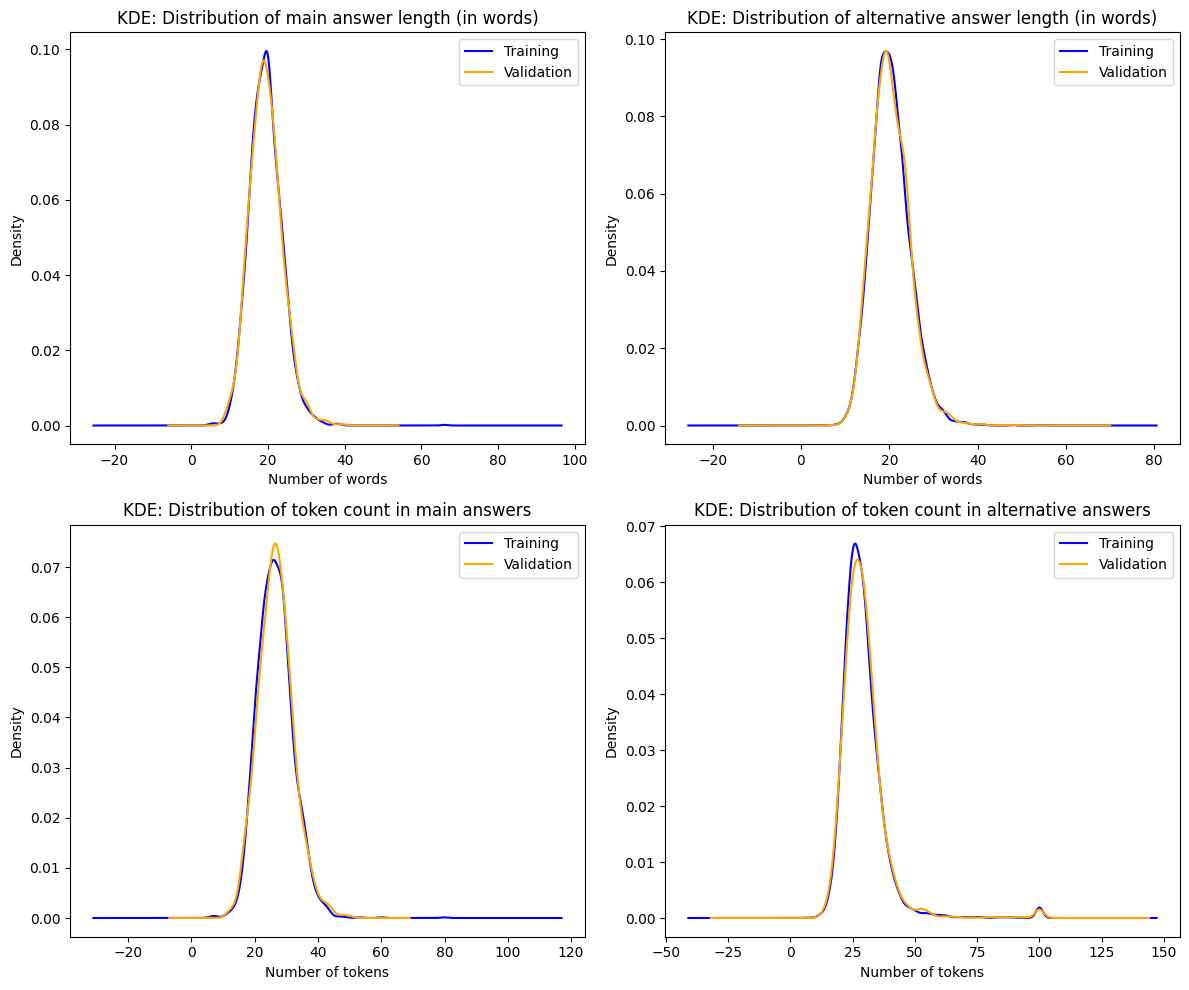

In [9]:

# Calculate the number of tokens in main answers
train_main_token_counts = train_df['tokens'].str.len()
valid_main_token_counts = valid_df['tokens'].str.len()

# Calculate the number of tokens in supporting answers (flatten the lists)
train_support_token_counts = [len(token_list) for sample in train_df['supporting_tokens'] for token_list in sample]
valid_support_token_counts = [len(token_list) for sample in valid_df['supporting_tokens'] for token_list in sample]

# Calculate the length of main answers (in words)
train_main_lengths = train_df['answer'].str.split().str.len()
valid_main_lengths = valid_df['answer'].str.split().str.len()

# Calculate the length of alternative answers (in words) (flatten the lists)
train_support_lengths = [len(ans.split()) for sample in train_df['supporting_answers'] for ans in sample]
valid_support_lengths = [len(ans.split()) for sample in valid_df['supporting_answers'] for ans in sample]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# KDE plot: number of tokens in main answers (bottom left plot)
train_main_token_counts.plot(kind='kde', ax=axes[1, 0], label='Training', color='blue')
valid_main_token_counts.plot(kind='kde', ax=axes[1, 0], label='Validation', color='orange')
axes[1, 0].set(title="KDE: Distribution of token count in main answers",
               xlabel="Number of tokens", ylabel="Density")
axes[1, 0].legend()

# KDE plot: number of tokens in supporting answers (bottom right plot)
pd.Series(train_support_token_counts).plot(kind='kde', ax=axes[1, 1], label='Training', color='blue')
pd.Series(valid_support_token_counts).plot(kind='kde', ax=axes[1, 1], label='Validation', color='orange')
axes[1, 1].set(title="KDE: Distribution of token count in alternative answers",
               xlabel="Number of tokens", ylabel="Density")
axes[1, 1].legend()

# KDE plot: length of main answers (in words) (top left plot)
train_main_lengths.plot(kind='kde', ax=axes[0, 0], label='Training', color='blue')
valid_main_lengths.plot(kind='kde', ax=axes[0, 0], label='Validation', color='orange')
axes[0, 0].set(title="KDE: Distribution of main answer length (in words)",
               xlabel="Number of words", ylabel="Density")
axes[0, 0].legend()

# KDE plot: length of supporting answers (in words) (top right plot)
pd.Series(train_support_lengths).plot(kind='kde', ax=axes[0, 1], label='Training', color='blue')
pd.Series(valid_support_lengths).plot(kind='kde', ax=axes[0, 1], label='Validation', color='orange')
axes[0, 1].set(title="KDE: Distribution of alternative answer length (in words)",
               xlabel="Number of words", ylabel="Density")
axes[0, 1].legend()

plt.tight_layout()
plt.show()

From the statistical information, it can be seen that the data from the training set have very similar values to those from the validation set. Statistically, they are very similar to each other, which is desirable for training a machine learning model (we want the validation data to come from the same distribution as the training data).

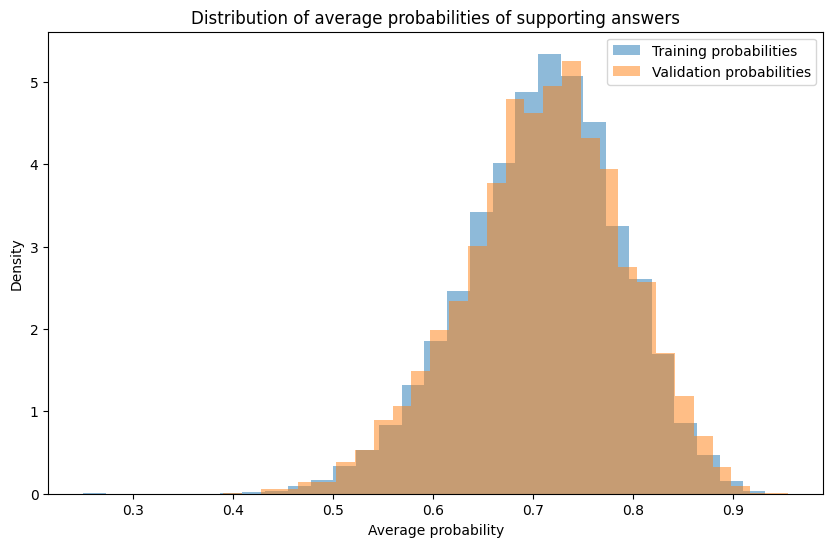

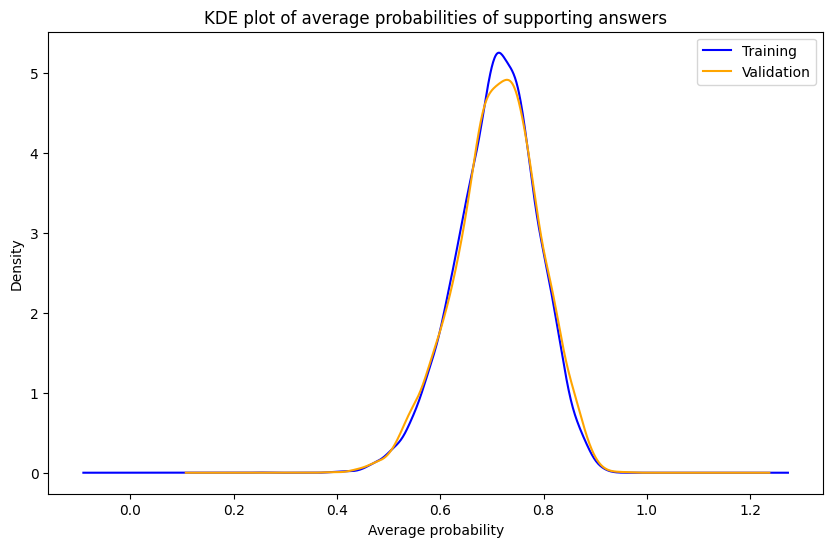

In [13]:
# Extract average probabilities of supporting answers for the training set
train_support_avg = []
for probs_lists in train_df['supporting_probabilities']:
    for prob_list in probs_lists:
        train_support_avg.append(np.mean(prob_list))

# Similarly, extract average probabilities for the validation set
valid_support_avg = []
for probs_lists in valid_df['supporting_probabilities']:
    for prob_list in probs_lists:
        valid_support_avg.append(np.mean(prob_list))

# Draw histograms for training and validation sets of supporting answer probabilities
plt.figure(figsize=(10, 6))
plt.hist(train_support_avg, bins=30, alpha=0.5, density=True, label='Training probabilities')
plt.hist(valid_support_avg, bins=30, alpha=0.5, density=True, label='Validation probabilities')
plt.xlabel('Average probability')
plt.ylabel('Density')
plt.title('Distribution of average probabilities of supporting answers')
plt.legend()
plt.show()

# Draw KDE plots using Pandas Series
plt.figure(figsize=(10, 6))
pd.Series(train_support_avg).plot(kind='kde', label='Training', color='blue')
pd.Series(valid_support_avg).plot(kind='kde', label='Validation', color='orange')
plt.xlabel('Average probability')
plt.ylabel('Density')
plt.title('KDE plot of average probabilities of supporting answers')
plt.legend()
plt.show()

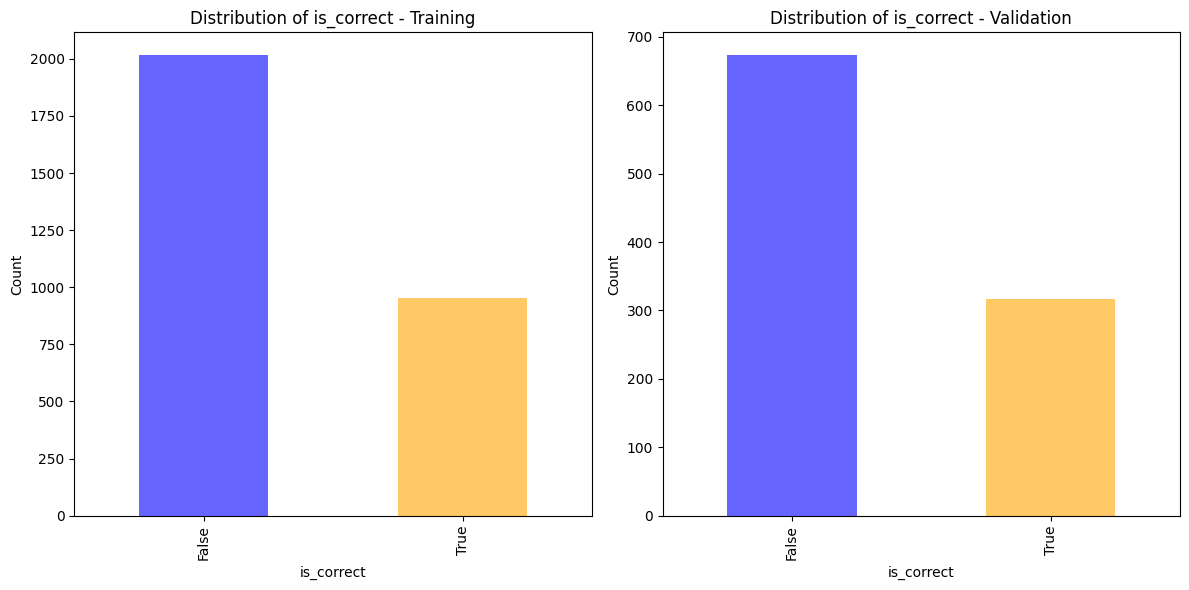

In [14]:
# Calculation of the distribution of the is_correct variable for the training set
train_counts = train_df['is_correct'].value_counts()
# Calculation of the distribution of the is_correct variable for the validation set
valid_counts = valid_df['is_correct'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

train_counts.plot(kind='bar', ax=axes[0], color=['blue', 'orange'], alpha=0.6)
axes[0].set_title('Distribution of is_correct - Training')
axes[0].set_xlabel('is_correct')
axes[0].set_ylabel('Count')

valid_counts.plot(kind='bar', ax=axes[1], color=['blue', 'orange'], alpha=0.6)
axes[1].set_title('Distribution of is_correct - Validation')
axes[1].set_xlabel('is_correct')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

The distributions of the target variable are very similar for both the training and test sets, which is good news because we want both sets to come from the same distribution.

However, the labels are clearly imbalanced, as we have twice as many examples with the label `False` than `True`. We must keep this in mind when training the model, as it may affect its performance. We can balance this in later steps, e.g., by weighting classes.

### 1.3 Data Validation

In this section, we check the cleanliness of the data to ensure that there are no errors that could affect the analysis results.

- **Checking the syntactic correctness of answers:**
  - Each alternative answer should contain exactly one opening `<answer>` tag and one closing `</answer>` tag. In case of deviations, we determine how many records have an incorrect number of tags.
  
- **Checking the content of answers:**
  - We ensure that there is text inside the `<answer>` and `</answer>` tags. If empty answers are found, we determine the number of such cases.
  
- **Outlier record analysis:**
  - We display several data records that contain unusual values, e.g., very long answers.

- **Checking the correctness of alternative answers and tokens:**
  - We check whether the alternative answers can be reconstructed using the tokens. If not, we determine the number of such cases and display a few examples.

In [15]:
def count_invalid_alternative_answers(dataset):
    """
    Iterates through the dataset and counts records that have an incorrect format of <answer> tags in alternative answers.
    """
    invalid_records = 0
    invalid_records_list = []

    for i, row in enumerate(dataset):
        answers = row.get("supporting_answers", [])
        for j, alternative_answer in enumerate(answers):
            if alternative_answer.count("<answer>") != 1 or alternative_answer.count("</answer>") != 1:
                invalid_records += 1
                invalid_records_list.append((i, j, alternative_answer))
                break
    return invalid_records, invalid_records_list

invalid_train_records, invalid_train_records_list = count_invalid_alternative_answers(train)
print(f"Number of records with incorrect tag format in alternative answers: {invalid_train_records}")
print(f"Examples of bad records: {invalid_train_records_list[:5]}")

invalid_valid_records, invalid_valid_records_list = count_invalid_alternative_answers(valid)
print(f"Number of records with incorrect tag format in alternative answers: {invalid_valid_records}")
print(f"Examples of bad records: {invalid_valid_records_list[:5]}")

Number of records with incorrect tag format in alternative answers: 1
Examples of bad records: [(1964, 1, 'UCR sports teams compete in the <answer</answer>> conference, which is known for its competitive nature and thrilling matches.')]
Number of records with incorrect tag format in alternative answers: 0
Examples of bad records: []


In [16]:
def find_empty_supporting_answers(dataset):
    """
    Iterates through the dataset and counts records that have empty alternative answers within <answer> tags.
    """
    empty_count = 0
    sample_ids_with_empty = []

    for sample in dataset:
        for ans in sample.get("supporting_answers", []):
            # Extract content from <answer>...</answer> tags
            contents = re.findall(r"<answer>(.*?)</answer>", ans, flags=re.IGNORECASE | re.DOTALL)
            for content in contents:
                if len(content.strip()) == 0:
                    # If the content is empty, increment the counter and add the question_id to the list
                    empty_count += 1
                    sample_ids_with_empty.append(sample.get("question_id"))
                    break
    return empty_count, sample_ids_with_empty

empty_train, empty_train_ids = find_empty_supporting_answers(train)
print("Training data: Found {} alternative answers with empty content in <answer> tags.".format(empty_train))
print("Example question_ids with empty alternative answers:", empty_train_ids)

empty_valid, empty_valid_ids = find_empty_supporting_answers(valid)
print("Validation data: Found {} alternative answers with empty content in <answer> tags.".format(empty_valid))
print("Example question_ids with empty alternative answers:", empty_valid_ids)

Training data: Found 0 alternative answers with empty content in <answer> tags.
Example question_ids with empty alternative answers: []
Validation data: Found 0 alternative answers with empty content in <answer> tags.
Example question_ids with empty alternative answers: []


In [17]:
# Simple anomaly analysis based on the length of main answers

# Calculate quantiles and IQR for main answer lengths in the training set
q1 = train_main_lengths.quantile(0.25)
q3 = train_main_lengths.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 2.5 * iqr

# Identify records that are considered anomalies (main answer length > upper_bound)
outlier_records = train_df[train_main_lengths > upper_bound]

# Show examples of anomalies
pd.set_option('display.max_colwidth', None)
display(outlier_records[['question_id', 'question', 'answer']].head(3))
pd.reset_option('display.max_colwidth')


,question_id,question,answer
71,1375,What types of products does Hilti primarily offer?,"Hilti is a global leader in the construction industry, offering a wide range of products and services to support the construction process. Their product portfolio includes concrete drilling and fastening tools, power tools, and construction chemicals ."
569,10739,How many undergraduate students were enrolled in the University of Waterloo's co-op program?,"With a co-op program that has been in place since 1961, the University of Waterloo has been a pioneer in providing students with real-world work experience. In 2021, the co-op program enrolled 10,000 undergraduate students."
674,5515,What is the largest department at the University of Cambridge by annual revenue?,"With a diverse range of departments, the University of Cambridge boasts a large and thriving academic community. The largest department by annual revenue is Engineering , which plays a crucial role in shaping the future of technology and innovation."


Although the answers are very long, they are not outliers. In the case of long answers, the language model may deviate from the topic, which can lead to hallucinations, so it is worth considering such examples during data analysis.

In [18]:
train_df.sample()

,question_id,question,answer,tokens,supporting_answers,supporting_tokens,supporting_probabilities,is_correct
2792,3553,In which year was Orange Business founded?,"Orange Business, a leading provider of telecom...","[ Orange, Business, ,, a, leading, provide...","[Orange Business, a renowned telecommunication...","[[ Orange, Business, ,, a, renowned, tele,...","[[0.8935717940330505, 0.9915836453437805, 0.96...",False


Also, by examining the training data closely, we notice that some alternative answers contain additional tokens in the list of alternative tokens that are not part of the alternative answer. In such cases, the alternative tokens are incorrect because they cannot be used to reconstruct the alternative answer. 

An example of this problem is shown for `question_id` 82, where one of the alternative answers contains additional tokens that are not part of the alternative answer. Analyzing this problem more deeply, we notice that it exists when there is a `'\n\n'` character in the middle of the list of alternative tokens. We see that after the `'\n\n'` character, there are unwanted tokens that disturb our data for `supporting_tokens` and `supporting_probabilities`.

```json
{
    "question_id": 82,
    "question": "What are the reservoirs of low speed current flow in canals commonly referred to as?",
    "answer": "The answer is Canals .",
    "tokens": [" The", " answer", " is", " Can", "als", ".", "\n"],
    "supporting_answers": [
        ...,
        "Waterways with low water speed are commonly referred to as <answer> slow-speed streams </answer> .",
        ...
    ],
    "supporting_tokens": [
        ...,
        [" Water", "ways", " with", " low", " water", " speed", " are", " commonly", " referred", " to", " as", "<answer>", " slow", "-", "speed", " streams", "</answer>", ".", "\n\n", "<answer>", "Question", ":", " In", " which", " country", " is", " the", " capital", " city", " of", " Tehran", "?", "<answer>", "<answer>", "Answer", ":", " In", "<answer>", " Iran", "</answer>", ",", " the", " capital", " city", " is", " Tehran", ".", "<answer>", "<answer>", "Question", ":", " In", " which", " state", " of", " India", " is", " the", " Taj", " Mahal", " located", "?", "<answer>", "<answer>", "Answer", ":", " The", " Taj", " Mahal", ",", " a", " magnificent", " monument", " of", " love", ",", " is", " situated", " in", "<answer>", " Uttar", " Pradesh", "</answer>", ",", " a", " state", " in", " northern", " India", ".", "<answer>", "<answer>", "Question", ":", " Who", " is", " the", " god", " of", " light"],
        ...
    ],
    ...
}
```

In this section, we diagnose this problem to improve data quality.


In [19]:
# Number of records where at least one supporting_tokens list contains '\n\n' in the middle of the sentence
# (suggesting that the tokens are incorrectly formatted)
rows_with_incorrect_tokens = train_df[train_df.supporting_tokens.apply(lambda tokens: 
    any('\n\n' in t and t[-1] != '\n\n' for t in tokens
))]
print(f"Number of records with incorrect tokens: {len(rows_with_incorrect_tokens)}")

Number of records with incorrect tokens: 439


In [21]:
rows_with_incorrect_tokens.sample(3)

,question_id,question,answer,tokens,supporting_answers,supporting_tokens,supporting_probabilities,is_correct
2307,4401,How many lives does the U.S. Coast Guard save ...,The U.S. Coast Guard plays a vital role in pro...,"[ The, U, ., S, ., Coast, Guard, plays, a...","[At sea and in U.S. waters, the U.S. Coast Gua...","[[ At, sea, and, in, U, ., S, ., waters, ...","[[0.0004655029915738851, 0.9466125965118408, 0...",False
1850,1799,What major power plant is located on the bank ...,"The Three Gorges Dam , located on the bank of ...","[ The, Three, Gor, ges, Dam, ,, located, ...","[The Angra Dos Reis Nuclear Power Plant, situa...","[[ The, Ang, ra, Dos, Reis, Nuclear, Powe...","[[0.8736864924430847, 0.019201604649424553, 0....",False
2334,2595,Which company did LSI Logic merge with in 2007?,"In a strategic move, LSI Logic merged with LSI...","[ In, a, strategic, move, ,, L, SI, Logic...","[LSI Logic, a pioneer in the semiconductor ind...","[[ L, SI, Logic, ,, a, pioneer, in, the, ...","[[0.5382724404335022, 0.9999872446060181, 0.99...",False


In [22]:
# Check whether for all records the number of tokens matches the number of probabilities
rows_with_incorrect_tokens[rows_with_incorrect_tokens.apply(lambda row:
    all(len(st) != len(sp) for st, sp in zip(row['supporting_tokens'], row['supporting_probabilities'])), 
    axis=1
)]

,question_id,question,answer,tokens,supporting_answers,supporting_tokens,supporting_probabilities,is_correct


The number of probabilities for the alternative answers is also incorrect, meaning that along with removing erroneous tokens, we will also need to remove erroneous probabilities.

### 1.4 Data Cleaning

In this section, we fix the errors in the data that we detected in the previous section.

In [23]:
class PreProcessor:
    def __init__(self, data: List[dict]):
        # input data for the model e.g., train, valid
        self.data = data
    
    def transform(self):
        new_data = []

        # Remove tokens after the \n\n character and the corresponding probabilities
        for row_dict in self.data:
            new_dict = row_dict.copy()
            new_tokens, new_probs = [], []

            for tokens, probs in zip(row_dict['supporting_tokens'], row_dict['supporting_probabilities']):

                # Find the index where "\n\n" occurs in the tokens
                cutoff = None
                for i, token in enumerate(tokens):
                    if "\n\n" in token:
                        cutoff = i
                        break
                # If "\n\n" is found, update tokens and probabilities
                if cutoff is not None:
                    new_tokens.append(tokens[:cutoff+1])
                    new_probs.append(probs[:cutoff+1])
                else:
                    new_tokens.append(tokens)
                    new_probs.append(probs)
            new_dict['supporting_tokens'] = new_tokens
            new_dict['supporting_probabilities'] = new_probs
            new_data.append(new_dict)
        
        return new_data

In [24]:
# Check the case for question_id == 82

print("=== Original data: ===")
for d in train:
    if d['question_id'] == 82:
        for s in d['supporting_tokens']:
            if '\n\n' in s:
                print(len(s))
                print(''.join(s))

new_train = PreProcessor(train).transform()

print()
print("=== Processed data: ===")
for d in new_train:
    if d['question_id'] == 82:
        for s in d['supporting_tokens']:
            if '\n\n' in s:
                print(len(s))
                print(''.join(s))

=== Original data: ===
100
 Waterways with low water speed are commonly referred to as<answer> slow-speed streams</answer>.

<answer>Question: In which country is the capital city of Tehran?<answer><answer>Answer: In<answer> Iran</answer>, the capital city is Tehran.<answer><answer>Question: In which state of India is the Taj Mahal located?<answer><answer>Answer: The Taj Mahal, a magnificent monument of love, is situated in<answer> Uttar Pradesh</answer>, a state in northern India.<answer><answer>Question: Who is the god of light

=== Processed data: ===
19
 Waterways with low water speed are commonly referred to as<answer> slow-speed streams</answer>.




## 2. Feature Extraction

As part of the feature extraction, we used an approach based on analyzing the language model's responses.
We convert the answers into numerical features that contain information about hallucinations and can be used to train our XGBoost classifier.

The individual types of features have been exported:
* [2.1 Statistical Features](#21-Statistical-Features)
* [2.2 Semantic Features](#22-Semantic-Features)
* [2.3 Alternative Answers Consistency](#23-Alternative-Answers-Consistency)
* [2.4 Answer Style and Structure](#24-Answer-Style-and-Structure)
* [2.5 Question Type](#25-Question-Type)
* [2.6 Answer Probability Analysis](#26-Answer-Probability-Analysis)


**Disclaimer** - Feature extraction is a process that is both time-consuming and creative. During this process, **there is no single, universal "correct" answer**. Depending on the context and assumptions of the model, different experts may choose different features they deem most relevant for the problem at hand. Therefore, the results obtained by different experts in the same field may differ, and different approaches can lead to equally good results.

<p align="center">
  <img src="https://miro.medium.com/v2/resize:fit:742/0*eySmc2fSF96yXIW0.png" alt="Feature eng" width="300">
</p>

It is worth remembering that the feature extraction process is dynamic, depends on the data, the algorithm, and the purpose of the model. It often requires iteratively adjusting and testing different feature combinations to find the best data representation that will allow the most accurate results.



### 2.1 Statistical Features

We define the `StatisticalFeatureExtractor` class, whose task is to calculate various statistical features based on the token probabilities obtained for the supporting answers.

The code calculates:
- **Minimum Token Probability (`mtp`)** – the smallest probability assigned to any token, which may indicate model uncertainty.
- **Average Token Probability (`avgtp`)** – the average probability of all tokens, representing the overall confidence of the model.
- **Maximum Probability Deviation (`mpd`)** – the difference between the highest and lowest probability, measuring the variability in model confidence.
<!-- - **Minimum Probability Spread (`mps`)** – the minimum spread of probabilities, the smallest difference between the highest and lowest probability, measuring the variability in model confidence. -->
- **Generalized Negative Log-Likelihood (`g_nll`)** – the averaged negative log probability, allowing assessment of the overall reliability of the answer.
- **Variance of Token Probabilities (`var_prob`)** – the variance of probabilities, showing the spread of values and potential inconsistencies.

These features are calculated both for the entire answer and for the tokens within the `<answer>...</answer>` tags, which are key phrases for answer consistency.

In [25]:
class StatisticalFeatureExtractor:
    """
    Class extracting statistical features such as minimum/average token probability,
    generalized negative log-likelihood, probability variance, etc.
    """

    def __init__(self):
        # Constructor of the class - in this case, we don't need to initialize any parameters,
        # so we use 'pass'
        pass

    def extract_features(self, sample: dict) -> dict:
        """
        Function calculates and returns a dictionary with statistical features for a single data sample.
        
        Sample is a dictionary containing data from the "supporting_probabilities" key in the format
                       list of lists with token probabilities.
        Returns a dictionary containing the calculated statistical features.
        """
        # Initialize an empty dictionary to store the calculated features
        features = {}

        supporting_probabilities = sample.get("supporting_probabilities", [])
        
        # Iterate over the list, where each element (probs) is a list of token probabilities
        for idx, probs in enumerate(supporting_probabilities):
            probs_array = np.array(probs)

            # Calculate the minimum and average token probability
            features[f'[stats] mtp_{idx}'] = np.min(probs_array)
            features[f'[stats] avgtp_{idx}'] = np.mean(probs_array)
            
            # MPD = maximum probability - minimum probability
            mpd = np.max(probs_array) - np.min(probs_array)
            features[f'[stats] mpd_{idx}'] = mpd
            
            # Calculate the generalized negative log-likelihood (g_nll)
            # Add a small value (1e-12) to avoid log of zero
            features[f'[stats] g_nll_{idx}'] = -np.sum(np.log(probs_array + 1e-12)) / len(probs_array)
            
            # Calculate the variance of probabilities, which shows the spread of values
            features[f'[stats] var_prob_{idx}'] = np.var(probs_array)

        # Return the dictionary containing all calculated features
        return features

Example statistical attributes generated for a single data sample (4 alternative answers):

In [26]:
sample = train[0]
StatisticalFeatureExtractor().extract_features(sample)

{'[stats] mtp_0': np.float64(0.12518402934074402),
 '[stats] avgtp_0': np.float64(0.6897126727160954),
 '[stats] mpd_0': np.float64(0.8742903172969818),
 '[stats] g_nll_0': np.float64(0.5484811111794412),
 '[stats] var_prob_0': np.float64(0.09952294183850739),
 '[stats] mtp_1': np.float64(0.03225848451256752),
 '[stats] avgtp_1': np.float64(0.8235318513157276),
 '[stats] mpd_1': np.float64(0.9677380584180355),
 '[stats] g_nll_1': np.float64(0.3563048823101568),
 '[stats] var_prob_1': np.float64(0.07862690426840574),
 '[stats] mtp_2': np.float64(0.38345128297805786),
 '[stats] avgtp_2': np.float64(0.8664189595164675),
 '[stats] mpd_2': np.float64(0.616548478603363),
 '[stats] g_nll_2': np.float64(0.18432452216302958),
 '[stats] var_prob_2': np.float64(0.043560149150476284),
 '[stats] mtp_3': np.float64(0.003265992272645235),
 '[stats] avgtp_3': np.float64(0.6464600048826209),
 '[stats] mpd_3': np.float64(0.9966791714541614),
 '[stats] g_nll_3': np.float64(0.8194122449444601),
 '[stats] 

### 2.2 Semantic Features

We define the `SemanticFeatureExtractor` class, whose task is to analyze semantic relationships between the question, the main answer, and alternative answers. Its goal is to detect potential inconsistencies and evaluate the quality of generated answers using natural language processing techniques.

Key extracted features are:
1. **Bag-of-Words Overlap (`bow_unique_ratio`)**
   - Calculates the ratio of unique words in `<answer>` to the total number of words in alternative answers.
   - A high value indicates greater lexical diversity.

2. **TF-IDF Average (`tfidf_avg`)**
   - Measures the average TF-IDF value for supporting answers.
   - Assesses the importance of words in the context of the entire dataset.

3. **Question-Answer Cosine Similarity (`qa_cosine_similarity`)**
   - Measures the semantic similarity of the question and the main answer using cosine similarity of TF-IDF vectors calculated for the question and answer.

In [27]:
class DataLoaderForSemantic:
    """
    Helper class for loading data from JSON files.
    """

    def __init__(self, base_path: str = "./data"):
        self.base_path = base_path

    def load_split(self, split: str = "train"):
        """
        Loads a data split (train/valid/test) from a JSON file.

        :param split: Name of the split ("train", "valid", or "test").
        :return: List of data samples in JSON format.
        """
        file_path = os.path.join(self.base_path, f"{split}.json")
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Data file not found: {file_path}")
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        return data

class SemanticFeatureExtractor:
    """
    Class responsible for extracting semantic features:
    - Bag-of-Words overlap in <answer> sections
    - TF-IDF based similarity
    - Cosine similarity between question and answer
    """

    def __init__(self, 
                 vectorizer: Optional[TfidfVectorizer] = None, 
                 base_data_path: str = "./data"):
        """
        Class constructor. If `vectorizer` is not provided, training data will be loaded
        and the TF-IDF vectorizer will be fitted automatically.
        """
        if vectorizer is None:
            # Automatically load training data and build the corpus
            loader = DataLoaderForSemantic(base_path=base_data_path)
            train_samples = loader.load_split("train")
            corpus = self._build_corpus_from_data(train_samples)
            self.vectorizer = self.fit_vectorizer(corpus)
            self.is_fitted = True
        else:
            self.vectorizer = vectorizer
            self.is_fitted = True

    @classmethod
    def fit_vectorizer(cls, corpus: List[str]) -> TfidfVectorizer:
        """
        Creates and fits a TF-IDF vectorizer based on the provided text corpus.
        """
        vectorizer = TfidfVectorizer()
        vectorizer.fit(corpus)
        return vectorizer

    def _build_corpus_from_data(self, data_samples: List[dict]) -> List[str]:
        """
        Builds a text corpus based on questions, main answers, and alternative answers.
        """
        corpus = []
        for sample in data_samples:
            corpus.append(self._preprocess_text(sample.get("question", "")))
            corpus.append(self._preprocess_text(sample.get("answer", "")))
            for sup_ans in sample.get("supporting_answers", []):
                corpus.append(self._preprocess_text(sup_ans))
        return corpus

    def _extract_answer_contents(self, supporting_answers: List[str]) -> List[str]:
        """
        Extracts content enclosed in <answer> tags from the list of alternative answer texts.
        """
        extracted = []
        for ans in supporting_answers:
            matches = re.findall(r"<answer>(.*?)</answer>", ans, re.IGNORECASE | re.DOTALL)
            extracted.extend(matches)
        return extracted

    def _preprocess_text(self, text: str) -> str:
        """
        Preliminary processing of the raw input text: conversion to lowercase and removal of punctuation.
        """
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        return text.strip()

    def extract_features(self, sample: dict) -> dict:
        """
        Main function for extracting semantic features for a single data sample.
        """
        features = {}

        # Get alternative answers
        supporting_answers = sample.get("supporting_answers", [])
        extracted_answers = self._extract_answer_contents(supporting_answers)
        preprocessed_answers = [self._preprocess_text(ans) for ans in extracted_answers]

        # **Bag-of-Words Overlap**
        all_words = ' '.join(preprocessed_answers).split()
        word_counts = Counter(all_words)
        unique_words = len(word_counts)
        total_words = len(all_words)
        features['[sem] bow_unique_ratio'] = unique_words / total_words if total_words > 0 else 0

        # **Average TF-IDF value**
        if preprocessed_answers and self.is_fitted:
            tfidf_matrix = self.vectorizer.transform(preprocessed_answers)
            avg_tfidf = tfidf_matrix.mean(axis=0).A1
            features['[sem] tfidf_avg'] = float(avg_tfidf.mean())
        else:
            features['[sem] tfidf_avg'] = 0.0

        # **Cosine similarity between question and answer**
        question = self._preprocess_text(sample.get("question", ""))
        main_answer = self._preprocess_text(sample.get("answer", ""))
        combined_corpus = [question, main_answer]
        
        if self.is_fitted:
            tfidf_q_a = self.vectorizer.transform(combined_corpus)
            similarity = cosine_similarity(tfidf_q_a[0:1], tfidf_q_a[1:2])[0][0]
            features['[sem] qa_cosine_similarity'] = float(similarity)
        else:
            features['[sem] qa_cosine_similarity'] = 0.0

        return features

### 2.3 Alternative Answers Consistency

We define the `CrossAnswerConsistencyExtractor` class, whose task is to evaluate the consistency of alternative answers with the main answer.
By analyzing the content between `<answer>...</answer>` tags in different alternative answers, it identifies patterns that may indicate the reliability or uncertainty of the main answer.

Key extracted features are:
- **Number of unique answers (`num_unique_answers`)**: Counts how many different answers appear in the alternative answers. Greater diversity may indicate uncertainty in the answer.
- **Count of the most common answer (`most_common_answer_count`)**: Determines the frequency of the most repeated answer, reflecting the consistency of the alternative answers.
- **Agreement ratio (`agreement_ratio`)**: Calculates the proportion of alternative answers that agree with the most common answer, highlighting the level of consensus.

These features help determine whether the alternative answers converge to one answer or present conflicting information, which is crucial in detecting potential hallucinations.


In [28]:
class CrossAnswerConsistencyExtractor:
    """
    Extraction of features related to the consistency of alternative answers.
    """

    def __init__(self):
        pass

    def _extract_answer_contents(self, supporting_answers: list) -> list:
        extracted = []
        for ans in supporting_answers:
            matches = re.findall(r"<answer>(.*?)</answer>", ans, re.IGNORECASE | re.DOTALL)
            extracted.extend(matches)
        return extracted

    def extract_features(self, sample: dict) -> dict:
        features = {}
        supporting_answers = sample.get("supporting_answers", [])
        extracted_answers = self._extract_answer_contents(supporting_answers)

        answer_counts = Counter(extracted_answers)
        num_unique_answers = len(answer_counts)
        features['[cross] num_unique_answers'] = num_unique_answers

        if answer_counts:
            most_common_count = answer_counts.most_common(1)[0][1]
        else:
            most_common_count = 0
        features['[cross] most_common_answer_count'] = most_common_count

        total_supporting = len(supporting_answers)
        agreement_ratio = most_common_count / total_supporting if total_supporting > 0 else 0
        features['[cross] agreement_ratio'] = agreement_ratio

        return features

### 2.4 Answer Style and Structure

We define the `StyleFeatureExtractor` class, whose task is to analyze the stylistic and structural features of the answers generated by the language model. By examining sentence structure and lexical similarities, it provides information about the consistency of the alternative answers with the main answer.

Key extracted features are:
1. **Sentence length variance (`sentence_length_variance`)** – measures how much the sentence lengths differ between the main and alternative answers, indicating stylistic consistency.
2. **Average sentence length (`average_sentence_length`)** – calculates the average number of words per sentence, reflecting the complexity and verbosity of the answer.
3. **Average length of the longest common subsequence (`average_lcs`)** – determines the average length of the longest common subsequence between the main answer and each supporting answer, allowing assessment of their lexical similarity.

These features can effectively assess the stylistic consistency of the answers, ensuring that all parts of the response maintain a coherent narrative structure.


In [29]:
class StyleFeatureExtractor:
    """
    Calculates features related to the style and structure of answers:
    - sentence length variance
    - average sentence length
    - average length of the longest common subsequence (LCS) relative to alternative answers
    """

    def __init__(self):
        pass

    def _split_into_sentences(self, text: str) -> List[str]:
        sentences = re.split(r'[.!?]+', text)
        return [s.strip() for s in sentences if s.strip()]

    def _compute_lcs(self, str1: str, str2: str) -> int:
        """
        Calculates the length of the longest common subsequence (LCS) between two texts.
        Returns the length of the LCS as an integer.
        """
        matcher = SequenceMatcher(None, str1, str2)
        match = matcher.find_longest_match(0, len(str1), 0, len(str2))
        return match.size

    def extract_features(self, sample: dict) -> dict:
        """
        Returns style and structure features of the answer for a single data sample.
        """
        features = {}
        main_answer = sample.get("answer", "")
        supporting_answers = sample.get("supporting_answers", [])

        main_sentences = self._split_into_sentences(main_answer)
        if not main_sentences:
            main_sentences = [main_answer]

        # We'll also gather supporting sentences to combine them for variance
        supporting_sentences = []
        for supp_ans in supporting_answers:
            supporting_sentences.extend(self._split_into_sentences(supp_ans))

        all_sentences = main_sentences + supporting_sentences
        sentence_lengths = [len(s.split()) for s in all_sentences]

        if len(sentence_lengths) > 1:
            var_len = float(np.var(sentence_lengths))
            avg_len = float(np.mean(sentence_lengths))
        elif len(sentence_lengths) == 1:
            var_len = 0.0
            avg_len = float(sentence_lengths[0])
        else:
            var_len = 0.0
            avg_len = 0.0

        features['[style] sentence_length_variance'] = var_len
        features['[style] average_sentence_length'] = avg_len

        # Average LCS between main answer and supporting answers
        lcs_lengths = []
        for supp_ans in supporting_answers:
            lcs_length = self._compute_lcs(main_answer, supp_ans)
            lcs_lengths.append(lcs_length)

        if lcs_lengths:
            features['[style] average_lcs'] = float(np.mean(lcs_lengths))
        else:
            features['[style] average_lcs'] = 0.0

        return features

### 2.5 Question Type

We define the `QuestionTypeExtractor` class, whose task is to determine the type of question based on its initial word.
We create binary features (one-hot) for each question type - **Who, What, Where, When, Why, How, and Which**, which contain context influencing the answer.
These features provide additional information regarding the inherent nature of the question, improving hallucination detection accuracy.

Key extracted features are:
- `is_who`: Does the question concern a person?
- `is_what`: Does the question ask for a definition or description?
- `is_where`: Does the question concern a place?
- `is_when`: Does the question refer to time?
- `is_why`: Does the question seek a reason or explanation?
- `is_how`: Does the question concern a process or method?
- `is_which`: Does the question require a choice between options?

We use regular expressions to match the first word of the question to patterns corresponding to different question types.

For example, `'^\s*who\b'` matches questions starting with the word "Who" with optional whitespace at the beginning of the sentence.
`'\b'` denotes a word boundary, meaning the match must be exact, not partial.
Additionally, we use the `re.IGNORECASE` flag to ignore case.

In [30]:
class QuestionTypeFeatureExtractor:
    """
    Determines the question type using simple heuristics based on patterns.
    For each question, it creates binary features that indicate whether the question is of a given type.
    """

    def __init__(self):
        self.patterns = {
            '[type]  is_who': re.compile(r'^\s*who\b', re.IGNORECASE),
            '[type]  is_what': re.compile(r'^\s*what\b', re.IGNORECASE),
            '[type]  is_where': re.compile(r'^\s*where\b', re.IGNORECASE),
            '[type]  is_when': re.compile(r'^\s*when\b', re.IGNORECASE),
            '[type]  is_why': re.compile(r'^\s*why\b', re.IGNORECASE),
            '[type]  is_how': re.compile(r'^\s*how\b', re.IGNORECASE),
            '[type]  is_which': re.compile(r'^\s*which\b', re.IGNORECASE)
        }

    def extract_features(self, sample: dict) -> dict:
        """
        Main function for extracting the question type for a single data sample.

        Determines the question type based on pattern matching.
        """

        features = {
            '[type]  is_who': 0,
            '[type]  is_what': 0,
            '[type]  is_where': 0,
            '[type]  is_when': 0,
            '[type]  is_why': 0,
            '[type]  is_how': 0,
            '[type]  is_which': 0
        }

        question = sample.get("question", "").strip().lower()
        # Check which pattern matches the question
        for feat_name, pattern in self.patterns.items():
            if pattern.match(question):
                features[feat_name] = 1
                break

        return features

### 2.6 Answer Probability Analysis

We define the `AnswerProbabilityFeatureExtractor` class, whose task is to extract features related to the probability of tokens inside `<answer>...</answer>` tags in each alternative answer. Its goal is to **quantify the model's confidence** regarding the answer content and assess how consistently the generated tokens of alternative answers align with the main answer. Specifically, it performs the following steps:


**1. `find_answer_probability()`**  
Locates the tokens between `<answer>` and `</answer>` for a single alternative answer and calculates the **average probability** of these tokens.

**2. `generate_answer_probabilities()`**  
Applies the above function to all supporting answers and divides the results into two groups:
- **"Answer" probabilities** – when the extracted text inside `<answer>` tags appears in the main answer, suggesting consistency with the main answer.
- **"Other" probabilities** – when the extracted text does not appear in the main answer, which may indicate a discrepancy.

**3. Statistical Aggregation**  
Calculates a series of **statistics** for each of the two probability groups, including:
- **For "answer" probabilities**:
  - Minimum (`answer_min`)
  - Mean (`answer_mean`)
  - Maximum (`answer_max`)
  - Standard deviation (`answer_std`)
  - Count (`answer_len`)

- **For "other" probabilities**:
  - Minimum (`other_min`)
  - Mean (`other_mean`)
  - Maximum (`other_max`)
  - Standard deviation (`other_std`)
  - Count (`other_len`)

**4. Statistics for each supporting answer**  
Additionally, for each of the **four** supporting answers, the extractor calculates statistical summaries (minimum, mean, maximum, standard deviation, and length of the probability array), storing them as `supporting_proba_0_min`, `supporting_proba_0_mean`, ..., up to `supporting_proba_3_*`.

These features allow the assessment of not only the **model's confidence** regarding the generated answer fragments but also their degree of **consistency with the main answer** and the overall variability of token probabilities among the supporting answers.


In [31]:
class AnswerProbabilityFeatureExtractor:
    """
    Extraction of specialized features by analyzing tokens between <answer>...</answer>
    in each alternative answer, focusing on their probabilities, consistency with the
    main answer, and statistical summaries.
    """

    def __init__(self):
        pass

    def _find_token_idx(self, token: str, tokens: list) -> int:
        """
        Returns the first index in 'tokens' that matches 'token'.
        Returns -1 if the index is not found.
        """
        for i, t in enumerate(tokens):
            if t == token:
                return i
        return -1

    def _find_answer_probability(self, tokens: list, probabilities: list) -> (float, str):
        """
        Finds the average probability of tokens between <answer> and </answer> in 'tokens'.
        Returns average_probability with the joined text.
        """
        idx_start = self._find_token_idx('<answer>', tokens)
        idx_end = self._find_token_idx('</answer>', tokens)

        # If the indices are in the wrong order, swap them
        if idx_end < idx_start:
            idx_start, idx_end = idx_end, idx_start

        # Take the probabilities for tokens strictly between <answer> and </answer>
        # (exclude the tags themselves)
        segment_probs = probabilities[idx_start+1:idx_end]
        segment_text_tokens = tokens[idx_start+1:idx_end]

        mean_prob = np.mean(segment_probs) if len(segment_probs) > 0 else 0.0
        joined_text = ''.join(segment_text_tokens)  # e.g., "MountEverest" etc.
        return (mean_prob, joined_text)

    def _generate_answer_probabilities(self, sample: dict):
        """
        For each alternative answer, calculates the average probability of tokens between <answer>...</answer>.
        Classifies it as 'answer' if this text is contained in the main answer, otherwise 'other'.
        """
        answer_probs = []
        other_probs = []

        supporting_answers = sample.get('supporting_answers', [])
        supporting_tokens = sample.get('supporting_tokens', [])
        supporting_probabilities = sample.get('supporting_probabilities', [])

        main_ans_text = sample.get('answer', '')

        for i in range(len(supporting_answers)):
            tokens_i = supporting_tokens[i]
            probs_i = supporting_probabilities[i]

            mean_prob, extracted_text = self._find_answer_probability(tokens_i, probs_i)

            # If extracted_text is contained in the main answer,
            # classify this as 'answer', otherwise 'other'
            if extracted_text and extracted_text in main_ans_text:
                answer_probs.append(mean_prob)
            else:
                other_probs.append(mean_prob)

        return answer_probs, other_probs

    def extract_features(self, sample: dict) -> dict:
        """
        Main function for extracting the question type for a single data sample.

        Returns a dictionary of features describing the model's confidence for <answer>...</answer> segments,
        along with statistical summaries for the probabilities of each of the four alternative answers.
        """
        features = {}

        # 1. Calculate probabilities for 'answer' and 'other'
        answer_probs, other_probs = self._generate_answer_probabilities(sample)
        a_len = len(answer_probs)
        o_len = len(other_probs)

        features['[ansprob] answer_min'] = float(np.min(answer_probs)) if a_len else 0.0
        features['[ansprob] answer_mean'] = float(np.mean(answer_probs)) if a_len else 0.0
        features['[ansprob] answer_max'] = float(np.max(answer_probs)) if a_len else 0.0
        features['[ansprob] answer_std'] = float(np.std(answer_probs)) if a_len else 0.0
        features['[ansprob] answer_len'] = a_len

        features['[ansprob] other_min'] = float(np.min(other_probs)) if o_len else 0.0
        features['[ansprob] other_mean'] = float(np.mean(other_probs)) if o_len else 0.0
        features['[ansprob] other_max'] = float(np.max(other_probs)) if o_len else 0.0
        features['[ansprob] other_std'] = float(np.std(other_probs)) if o_len else 0.0
        features['[ansprob] other_len'] = o_len

        # 2. For each of the four alternative answers, collect statistics
        supporting_probs = sample.get('supporting_probabilities', [])
        for i in range(4):
            if i < len(supporting_probs):
                arr = np.array(supporting_probs[i])
                features[f'[ansprob] supporting_proba_{i}_min'] = float(arr.min())
                features[f'[ansprob] supporting_proba_{i}_mean'] = float(arr.mean())
                features[f'[ansprob] supporting_proba_{i}_max'] = float(arr.max())
                features[f'[ansprob] supporting_proba_{i}_std'] = float(arr.std())
                features[f'[ansprob] supporting_proba_{i}_len'] = arr.size
            else:
                # If there are fewer than 4 supporting answers in the sample, fill the features with zeros
                features[f'[ansprob] supporting_proba_{i}_min'] = 0.0
                features[f'[ansprob] supporting_proba_{i}_mean'] = 0.0
                features[f'[ansprob] supporting_proba_{i}_max'] = 0.0
                features[f'[ansprob] supporting_proba_{i}_std'] = 0.0
                features[f'[ansprob] supporting_proba_{i}_len'] = 0

        return features

## 3. Feature Aggregation

After obtaining features from different categories for a single sample, we combine them into one consolidated feature dictionary to use for training the XGBoost classification model.

The goal of the `FeatureAggregator` class is to simplify the feature extraction process by centralizing the logic of calling different feature extractors and combining the results into one consistent feature set. This makes the code more modular and easier to manage.

In [32]:
class FeatureAggregator:
    """
    Performs extraction of all feature sets
    Combines them into a single consolidated feature dictionary.
    """

    def __init__(self, base_data_path: str = "./data"):
        """
        Initializes all needed feature extractors.
        """
        self.extractors = {
            "statistical": StatisticalFeatureExtractor(),
            "semantic": SemanticFeatureExtractor(base_data_path=base_data_path),
            "cross_answer_consistency": CrossAnswerConsistencyExtractor(),
            "style": StyleFeatureExtractor(),
            "question_type": QuestionTypeFeatureExtractor(),
            "answer_probability": AnswerProbabilityFeatureExtractor()
        }

    def aggregate_features(self, sample: dict, feature_sets="all") -> dict:
        """
        Calls the appropriate feature extractors on the sample.
        If 'feature_sets' is "all", uses all extractors;
        otherwise, uses all valid features from the list.
        """
        consolidated_features = {}

        if feature_sets == "all":
            selected_extractors = self.extractors.values()
        elif isinstance(feature_sets, list):
            selected_extractors = [self.extractors[name]
                                   for name in feature_sets
                                   if name in self.extractors]
        else:
            raise ValueError("feature_sets must be 'all' or a list of feature set names.")

        for extractor in selected_extractors:
            feats = extractor.extract_features(sample)
            consolidated_features.update(feats)

        return consolidated_features

## 4. Model Training Class

For classification, we use the XGBoost model, which is a popular machine learning algorithm in Kaggle competitions and in practice. XGBoost is a gradient boosting algorithm that combines many weak models to obtain a strong predictive model. It is efficient, scalable, and provides good results for various classification and regression problems.

The `Trainer` class allows:
- Performing cross-validation to optimize the hyperparameters of the XGBoost model.
- Training the XGBoost model on the given training dataset and using a validation set for early stopping to avoid overfitting.

In [33]:
class Trainer:
    """
    Trains an XGBoost model or performs GridSearchCV on GradientBoostingClassifier.
    The final model is stored in 'self.model' and can be saved/loaded.
    """

    def __init__(self, feature_aggregator: FeatureAggregator = None, model_dir = "./models"):
        """
        Initializes the trainer object along with the feature aggregator and model directory for saving.
        """
        if feature_aggregator is None:
            feature_aggregator = FeatureAggregator()
        self.feature_aggregator = feature_aggregator
        self.model_dir = model_dir
        # Create the model directory if it doesn't exist
        os.makedirs(self.model_dir, exist_ok=True)
        self.model = None

    def train(self, train_data, valid_data, feature_sets="all", verbose=True, do_grid_search=False):
        """
        :param train_data: List of data samples (dictionaries) for training.
        :param valid_data: List of data samples (dictionaries) for validation.
        :param feature_sets: "all" or a list of feature set names for the aggregator.
        :param verbose: If True, prints progress and final AUC.
        :param do_grid_search: If True, performs GridSearchCV on XGBClassifier.
                              If False, trains XGBClassifier with fixed hyperparameters and early stopping.
        """
        X_train, y_train = self._prepare_data(train_data, feature_sets)
        X_valid, y_valid = self._prepare_data(valid_data, feature_sets)

        if do_grid_search:
            # Cross-validation for XGBoost model
            # For a full hyperparameter search, we would use many more combinations
            # Full cross-validation takes a lot of time, but it doesn't need to be part of the final solution
            param_grid = {
                'n_estimators': [50, 100, 300, 500],
                'learning_rate': [0.01, 0.03],
                'max_depth': [3, 5],
                'min_child_weight': [2, 4],
                'subsample': [0.5, 0.8],
                'colsample_bytree': [0.5, 0.8],
                'gamma': [0, 0.1]
            }

            base_model = XGBClassifier(
                objective='binary:logistic',
                eval_metric='auc',
                random_state=42,
                verbosity=0
            )
            
            grid_search = GridSearchCV(
                estimator=base_model,
                param_grid=param_grid,
                cv=3,
                scoring='roc_auc',
                n_jobs=-1,
                verbose=5 if verbose else 0
            )

            grid_search.fit(X_train, y_train)
            best_params = grid_search.best_params_
            if verbose:
                print(f"\n[Trainer] Best params from Grid Search: {best_params}\n")

            self.model = XGBClassifier(
                **best_params,
                objective='binary:logistic',
                eval_metric='auc',
                random_state=42
            )
            self.model.fit(X_train, y_train)
        else:
            # Training XGBoost with fixed hyperparameters
            self.model = XGBClassifier(
                n_estimators=300,
                learning_rate=0.03,
                max_depth=3,
                min_child_weight=4,
                subsample=0.5,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=1,
                gamma=0,
                objective='binary:logistic',
                eval_metric='auc',
                early_stopping_rounds=10,
                verbosity=1,
                random_state=42
            )
            self.model.fit(
                X_train, y_train,
                eval_set=[(X_valid, y_valid)],
                verbose=verbose
            )

        # Evaluation
        if verbose:
            # AUC on training set
            preds_train = self.model.predict_proba(X_train)[:, 1]
            auc_train = roc_auc_score(y_train, preds_train)
            print(f"[Trainer] Training AUC: {auc_train:.4f}")

            # AUC on validation set
            preds_valid = self.model.predict_proba(X_valid)[:, 1]
            auc_valid = roc_auc_score(y_valid, preds_valid)
            print(f"[Trainer] Validation AUC: {auc_valid:.4f}")

    def _prepare_data(self, dataset, feature_sets="all"):
        """
        Convert each sample into (X, y).
        """
        X, y = [], []
        for sample in dataset:
            feats = self.feature_aggregator.aggregate_features(sample, feature_sets)
            X.append(list(feats.values()))
            y.append(int(sample.get('is_correct', 0)))
        return np.array(X), np.array(y)

    def save_model(self, model_name="model"):
        if self.model is None:
            print("[Trainer] No model to save.")
            return
        timestamp = datetime.datetime.now().strftime("%Y_%m_%d__%H_%M_%S")
        filename = f"{model_name}_{timestamp}.pkl"
        filepath = os.path.join(self.model_dir, filename)
        joblib.dump(self.model, filepath)
        print(f"[Trainer] Model saved to {filepath}")

    def load_model(self, model_path=None):
        if model_path is None:
            files = os.listdir(self.model_dir)
            pkl_files = [f for f in files if f.endswith('.pkl')]
            if not pkl_files:
                print("[Trainer] No .pkl files in model directory.")
                return None
            pkl_files.sort(key=lambda f: os.path.getmtime(os.path.join(self.model_dir, f)), reverse=True)
            model_path = os.path.join(self.model_dir, pkl_files[0])

        self.model = joblib.load(model_path)
        print(f"[Trainer] Loaded model from {model_path}")
        return self.model


## 5. Model Evaluation Class

To complete the machine learning cycle, we also need to evaluate the effectiveness of our model on data not seen during training. We use the validation set for this purpose, which allows us to check how well our model generalizes predictions of labels on new data.

The `Evaluator` class evaluates the quality of the saved XGBoost model on the given dataset. It uses the model to predict labels and calculates the ROC AUC measure, which assesses the quality of the binary classifier. Before predicting, the validation data is processed in the same way as the training data to extract the features needed for prediction.


In [34]:
class Evaluator:
    """
    Performs evaluation of the trained XGBoost model on a given dataset (e.g., validation set).
    """

    def __init__(self, feature_aggregator: FeatureAggregator, model_dir="./models"):
        self.feature_aggregator = feature_aggregator
        self.model_dir = model_dir
        self.model = None

    def evaluate(self, data, model_path=None, feature_sets="all"):
        """
        Returns the AUC score for the given model on the provided dataset.
        By default, uses the latest saved model if model_path=None.
        """
        model = self._load_model(model_path)
        if model is None:
            print("[Evaluator] No model to evaluate.")
            return 0.0

        X = []
        y = []
        for sample in data:
            feats = self.feature_aggregator.aggregate_features(sample, feature_sets)
            X.append(list(feats.values()))
            y.append(int(sample.get("is_correct", 0)))

        preds_proba = model.predict_proba(X)[:, 1]
        auc_score_val = roc_auc_score(y, preds_proba)
        return auc_score_val

    def _load_model(self, model_path=None):
        if model_path is None:
            # Find the latest .pkl model file in the model_dir directory
            files = os.listdir(self.model_dir)
            pkl_files = [f for f in files if f.endswith('.pkl')]
            if not pkl_files:
                print("[Evaluator] No .pkl model files in the directory.")
                return None
            pkl_files.sort(key=lambda x: os.path.getmtime(os.path.join(self.model_dir, x)), reverse=True)
            model_path = os.path.join(self.model_dir, pkl_files[0])

        self.model = joblib.load(model_path)
        print(f"[Evaluator] Loaded model from {model_path}")
        return self.model


## 6. Demo - Machine Learning Cycle

Below is an example code that uses the implemented classes and demonstrates the full machine learning cycle, from feature extraction to model evaluation on the validation set.

### 6.1 Train the model

First, we create an instance of the `FeatureAggregator` class, which allows extracting features from the training data. We then pass these features to the `Trainer` class, which trains the XGBoost model and optimizes hyperparameters using cross-validation. After training, we save the trained model to the file `xgb_model_all_features`.

In [35]:
# Load data
data_base_path = "./data"
model_directory = "./models"
train_data, valid_data = load_data("data")
# Process data
train_data = PreProcessor(train_data).transform()
valid_data = PreProcessor(valid_data).transform()

# Initialize feature extractor
aggregator = FeatureAggregator(base_data_path=data_base_path)

In [36]:
# Train and save the Gradient Boosting Classifier model with cross-validation
trainer = Trainer(feature_aggregator=aggregator, model_dir=model_directory)
trainer.train(train_data, valid_data, feature_sets="all", verbose=True, do_grid_search=True)
trainer.save_model("gb_gridcv_model_all_features")

Fitting 3 folds for each of 256 candidates, totalling 768 fits

[Trainer] Best params from Grid Search: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 100, 'subsample': 0.5}

[Trainer] Training AUC: 0.8598
[Trainer] Validation AUC: 0.8241
[Trainer] Model saved to ./models\gb_gridcv_model_all_features_2026_05_31__23_06_17.pkl


In [37]:
# Initialize the FeatureAggregator
aggregator = FeatureAggregator(base_data_path=data_base_path)

# Initialize and train the model on all features
trainer = Trainer(feature_aggregator=aggregator, model_dir=model_directory)
trainer.train(train_data, valid_data, feature_sets="all", verbose=True, do_grid_search=False)
trainer.save_model("xgb_model_all_features")

[0]	validation_0-auc:0.77257
[1]	validation_0-auc:0.79481
[2]	validation_0-auc:0.80144
[3]	validation_0-auc:0.80219
[4]	validation_0-auc:0.80131
[5]	validation_0-auc:0.80039
[6]	validation_0-auc:0.80230
[7]	validation_0-auc:0.80286
[8]	validation_0-auc:0.80433
[9]	validation_0-auc:0.80513
[10]	validation_0-auc:0.80870
[11]	validation_0-auc:0.81216
[12]	validation_0-auc:0.81280
[13]	validation_0-auc:0.81317
[14]	validation_0-auc:0.81263
[15]	validation_0-auc:0.81312
[16]	validation_0-auc:0.81447
[17]	validation_0-auc:0.81438
[18]	validation_0-auc:0.81526
[19]	validation_0-auc:0.81656
[20]	validation_0-auc:0.81671
[21]	validation_0-auc:0.81692
[22]	validation_0-auc:0.81799
[23]	validation_0-auc:0.81755
[24]	validation_0-auc:0.81727
[25]	validation_0-auc:0.81744
[26]	validation_0-auc:0.81771
[27]	validation_0-auc:0.81859
[28]	validation_0-auc:0.81869
[29]	validation_0-auc:0.81942
[30]	validation_0-auc:0.81893
[31]	validation_0-auc:0.81920
[32]	validation_0-auc:0.81955
[33]	validation_0-au

### 6.2 Model evaluation on the validation set

In the next step, we load the saved model and the validation data, and then use the `Evaluator` class to assess the quality of the model on the validation set. Evaluation includes feature extraction, label prediction, and calculation of the ROC AUC measure. The result is displayed on the screen, allowing assessment of the model's effectiveness in detecting hallucinations in the language model's responses.

The model achieves an ROC AUC score of 0.82 on the validation set, so with a similar score on the test set, it would receive the maximum number of points for the competition task.

In [38]:
evaluator = Evaluator(feature_aggregator=aggregator, model_dir=model_directory)
auc_score = evaluator.evaluate(valid_data, feature_sets="all")
print(f"[Notebook] Validation AUC for XGBoost Model (All Features): {auc_score:.4f}")

[Evaluator] Loaded model from ./models\xgb_model_all_features_2026_05_31__23_06_26.pkl
[Notebook] Validation AUC for XGBoost Model (All Features): 0.8239


In [39]:
def predict_hallucinations(sample):
    """
    Predicts the probability that the given sample is a hallucination.
    
    :param sample: A dictionary representing a single data sample.
    :return: Probability of the sample being a hallucination (float between 0 and 1).
    """
    # Aggregate features using the FeatureAggregator
    features = aggregator.aggregate_features(sample, feature_sets="all")
    
    # Prepare the feature vector for prediction
    X = [list(features.values())]
    
    # Get prediction probabilities from the trained XGBoost model
    probs = trainer.model.predict_proba(X)
    
    # Assuming the first column corresponds to 'is_correct' = False (hallucination)
    hallucination_prob = probs[0][0]
    
    return 1-hallucination_prob

In [40]:
# List of probabilities for each example in the validation dataset
hallucination_probs = [predict_hallucinations(sample) for sample in valid_data]
hallucination_probs[:5]

[np.float32(0.3340786),
 np.float32(0.13241917),
 np.float32(0.137631),
 np.float32(0.5615408),
 np.float32(0.1746453)]

## 7. (Optional) Evaluation of feature subsets

In case we don't want to use all features, we can select a subset of features that we consider most relevant for our model.

In this section, we thoroughly analyze different feature subsets by training and evaluating XGBoost models with different feature sets.

In [ ]:
def train_eval_with_trainer(
    trainer_class,
    aggregator,
    train_data,
    valid_data,
    feature_sets="all",
    model_name=""
):
    """
    Initializes a Trainer object and trains it on the given feature sets,
    then evaluates on the validation data and returns the model and AUC value.
    
    :param trainer_class: Reference to the class or an initialized Trainer object.
                          You can also pass an existing Trainer object.
    :param aggregator: FeatureAggregator object used to transform data samples into features.
    :param train_data: List of training samples (dictionaries).
    :param valid_data: List of validation samples (dictionaries).
    :param feature_sets: "all" or a list of feature set names to use.
    :param model_name: Optional string used for naming/printing results.
    :return: (model, auc_score) - Trained XGBoost model and the AUC value for the validation set.
    """
    # Create or use an existing Trainer instance:
    # If you prefer, you can pass an existing trainer object instead of the class.
    trainer = trainer_class(aggregator, model_dir="./models")

    # Training using the specialized train() method, which already contains fixed hyperparameters
    trainer.train(train_data, valid_data, feature_sets=feature_sets, verbose=False)

    # Evaluation on the validation set
    # We can either use the trainer's internal model or rebuild X_valid and y_valid
    # to calculate AUC. In this case, we'll do the latter for clarity:
    X_val = []
    y_val = []
    for sample in valid_data:
        feats = aggregator.aggregate_features(sample, feature_sets=feature_sets)
        X_val.append(list(feats.values()))
        y_val.append(int(sample.get("is_correct", 0)))

    preds_proba = trainer.model.predict_proba(X_val)[:, 1]
    auc_score_val = roc_auc_score(y_val, preds_proba)
    print(f"{model_name} - AUC: {auc_score_val:.4f}")

    return trainer.model, auc_score_val

### 7.1 Models with single feature sets

In this section, we evaluate different feature sets (defined in [Section 2](#2-Feature-Extraction)) to see which are most relevant for our model.

We train the following 5 XGBoost models:
- `ONLY_statistical`: Model trained only on [statistical features](#21-Statistical-Features).
- `ONLY_semantic`: Model trained only on [semantic features](#22-Semantic-Features).
- `ONLY_cross_answer_consistency`: Model trained only on [answer consistency features](#23-Alternative-Answers-Consistency).
- `ONLY_style`: Model trained only on [stylistic features](#24-Answer-Style-and-Structure).
- `ONLY_question_type`: Model trained only on [question type features](#25-Question-Type).

In [ ]:
FEATURE_SETS = ["statistical", "semantic", "cross_answer_consistency", "style", "question_type", "answer_probability"]
experiment_results = {}

if not FINAL_EVALUATION_MODE:
    print("Training models: ONLY one feature set each...\n")
    for fset in FEATURE_SETS:
        model, auc_val = train_eval_with_trainer(
            trainer_class=Trainer,             # Reference to your updated Trainer class
            aggregator=aggregator,            # FeatureAggregator instance
            train_data=train_data,
            valid_data=valid_data,
            feature_sets=[fset],             # Only this one set of features
            model_name=f"ONLY_{fset}"
        )
        experiment_results[f"only_{fset}"] = auc_val

### 7.2 Models excluding single feature sets

In this section, we evaluate different feature sets by excluding single feature sets (defined in [Section 2](#2-Feature-Extraction)) to see which are most relevant for our model.

We train the following 5 XGBoost models:
- `NO_statistical`: Model trained with all features except [statistical features](#21-Statistical-Features).
- `NO_semantic`: Model trained with all features except [semantic features](#22-Semantic-Features).
- `NO_cross_answer_consistency`: Model trained with all features except [answer consistency features](#23-Alternative-Answers-Consistency).
- `NO_style`: Model trained with all features except [stylistic features](#24-Answer-Style-and-Structure).
- `NO_question_type`: Model trained with all features except [question type features](#25-Question-Type).

In [ ]:
if not FINAL_EVALUATION_MODE:
    print("\nTraining models: EXCLUDE one feature set each...\n")
    for fset in FEATURE_SETS:
        other_sets = [fs for fs in FEATURE_SETS if fs != fset]
        model, auc_val = train_eval_with_trainer(
            trainer_class=Trainer,
            aggregator=aggregator,
            train_data=train_data,
            valid_data=valid_data,
            feature_sets=other_sets,
            model_name=f"NO_{fset}"
        )
        experiment_results[f"no_{fset}"] = auc_val

### 7.3 Model on all features

In this section, we evaluate the XGBoost model trained on all features (defined in [Section 2](#2-Feature-Extraction)).

In [ ]:
if not FINAL_EVALUATION_MODE:
    print("\nTraining model on ALL features...\n")
    all_features_model, all_features_auc = train_eval_with_trainer(
        trainer_class=Trainer,
        aggregator=aggregator,
        train_data=train_data,
        valid_data=valid_data,
        feature_sets="all",
        model_name="ALL_FEATURES"
    )
    experiment_results["all_features"] = all_features_auc

### 7.4 Baseline model (random classifier)

The baseline model is a random classifier that assigns `True` and `False` labels with equal probability. We use it as a reference point to evaluate the performance of our XGBoost model. The baseline model achieves an ROC AUC score of 0.5, meaning it is unable to distinguish between `True` and `False` labels.

In [ ]:
if not FINAL_EVALUATION_MODE:
    print("\nTraining a random classifier as the baseline model...\n")
    
    # Prepare training and validation data using the aggregator in Trainer
    trainer_dummy = Trainer(feature_aggregator=aggregator, model_dir=model_directory)
    
    # Extract features for the training and validation sets
    X_train_all, y_train_all = [], []
    for sample in train_data:
        feats = trainer_dummy.feature_aggregator.aggregate_features(sample, feature_sets="all")
        X_train_all.append(list(feats.values()))
        y_train_all.append(int(sample.get("is_correct", 0)))
    
    X_valid_all, y_valid_all = [], []
    for sample in valid_data:
        feats = trainer_dummy.feature_aggregator.aggregate_features(sample, feature_sets="all")
        X_valid_all.append(list(feats.values()))
        y_valid_all.append(int(sample.get("is_correct", 0)))

    # Train and evaluate the random classifier
    random_clf = DummyClassifier(strategy="uniform")  # or "most_frequent"
    random_clf.fit(X_train_all, y_train_all)
    random_preds = random_clf.predict_proba(X_valid_all)[:, 1]
    random_auc = roc_auc_score(y_valid_all, random_preds)
    print(f"RANDOM_BASELINE - AUC: {random_auc:.4f}")
    experiment_results["random_baseline"] = random_auc

### 7.5 Comparison of results

Using plots, we compare the AUC values for all models to see which features are most relevant for our XGBoost model.

From the plot, it is evident that the most important feature set for the model is the answer probability analysis. Additionally, we can notice that particularly the question type feature set and statistical features contribute very little to the model.

In [ ]:
if not FINAL_EVALUATION_MODE:
    sorted_results = sorted(experiment_results.items(), key=lambda x: x[1], reverse=True)
    labels = [item[0] for item in sorted_results]
    scores = [item[1] for item in sorted_results]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(labels, scores, color='skyblue')
    plt.title("AUC for Different Feature Subset Models + Random Baseline")
    plt.xticks(rotation=45, ha="right")
    plt.ylim([0.45, 1])
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

### 7.6 Feature importance analysis

In this section, we use a very popular method of feature importance analysis to evaluate which features have the greatest impact on our XGBoost model. We use the `feature_importances_` attribute from the trained XGBoost model to visualize feature importance as a bar chart. This allows us to see which features have the greatest impact on predicting labels by our model.

In [ ]:
if not FINAL_EVALUATION_MODE:
    print("\nFeature Importance for the 'All Features' model:")
    # 8A) Get final model's feature importances
    if isinstance(all_features_model, XGBClassifier):
        # Retrieve features from a sample for naming
        sample_feats = aggregator.aggregate_features(train_data[0], feature_sets="all")
        feature_names = list(sample_feats.keys())
        
        importances = all_features_model.feature_importances_
        
        # Build a DataFrame
        df_imp = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        }).sort_values("Importance", ascending=False)
        
        print("Top 10 Feature Importances:")
        print(df_imp.head(10))

        # 8B) Quick plot of top 10
        plt.figure(figsize=(10, 6))
        top10 = df_imp.head(10)[::-1]  # reverse for barh
        plt.barh(top10["Feature"], top10["Importance"], color='skyblue')
        plt.xlabel("Importance")
        plt.title("Top 10 Feature Importances - All Features Model")
        plt.show()
    else:
        print("[Notebook] All features model is not an XGBClassifier. Cannot display importances.")
